# Recommender Systems: Item-Based CF vs SVD


## 1. Load Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(df.shape)
df.head()

(24053764, 4)


,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


## 2. Filter & Subsample

In [2]:
# Keep only active users (>=100 ratings)
user_counts = df.groupby("user_id").size()
active_users = user_counts[user_counts >= 100].index
small_df = df[df["user_id"].isin(active_users)]

# Sample 5000 users
sample_users = (
    small_df["user_id"]
    .drop_duplicates()
    .sample(5000, random_state=42)
)
cf_df = small_df[small_df["user_id"].isin(sample_users)]

# Keep popular movies only
movie_counts = cf_df.groupby("movie_id").size()
popular_movies = movie_counts[movie_counts >= 40].index
cf_df = cf_df[cf_df["movie_id"].isin(popular_movies)].copy()

print(f"Users : {cf_df['user_id'].nunique()}")
print(f"Movies: {cf_df['movie_id'].nunique()}")
print(f"Rows  : {cf_df.shape[0]}")

Users : 5000
Movies: 1813
Rows  : 901682


## 3. Per-User Train/Test Split

**This is the most important fix.**

A global random split (`train_test_split` on all rows) means many test users have
**zero training history** — Item-CF cannot make any predictions for them, so it
scores 0. SVD can still predict via its global latent factors, giving it an
unfair advantage.

The correct approach is a **per-user split**: for every user, hold out 20 % of
their ratings as test and keep 80 % in train.  This guarantees every test user
has training history that both models can use.

In [3]:
def train_test_split_by_user(df, test_size=0.2, min_interactions=5, random_state=42):
    """
    Split ratings PER USER so every test user has training history.
    Users with fewer than min_interactions ratings are dropped entirely.
    """
    rng = np.random.default_rng(random_state)
    train_rows, test_rows = [], []

    for user_id, group in df.groupby("user_id"):
        if len(group) < min_interactions:
            train_rows.append(group)   # too few ratings -> all go to train
            continue

        n_test = max(1, int(len(group) * test_size))
        test_idx = rng.choice(group.index, size=n_test, replace=False)
        mask = group.index.isin(test_idx)
        test_rows.append(group[mask])
        train_rows.append(group[~mask])

    train = pd.concat(train_rows).reset_index(drop=True)
    test  = pd.concat(test_rows).reset_index(drop=True)
    return train, test


train_df, test_df = train_test_split_by_user(
    cf_df,
    test_size=0.2,
    min_interactions=5,
    random_state=42,
)

print(f"Train: {train_df.shape}  |  unique users: {train_df['user_id'].nunique()}")
print(f"Test : {test_df.shape}   |  unique users: {test_df['user_id'].nunique()}")

# Sanity check: every test user must exist in train
test_users_in_train = test_df["user_id"].isin(train_df["user_id"]).all()
print(f"All test users have training history: {test_users_in_train}")

Train: (723327, 4)  |  unique users: 5000
Test : (178355, 4)   |  unique users: 5000
All test users have training history: True


## 4. Shared Evaluation Setup

In [4]:
RELEVANCE_THRESHOLD = 3.5   # same as reference notebook
K = 10

# Relevant items per user (from test set only)
relevant_movies = (
    test_df[test_df["rating"] >= RELEVANCE_THRESHOLD]
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

# Movies each user already watched in train (exclude from recommendations)
train_user_movies = (
    train_df.groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

# Shared candidate pool = movies present in train_df
candidate_pool = set(train_df["movie_id"].unique())
candidate_list = list(candidate_pool)  # for SVD iteration

# Eval users = test users who have at least 1 relevant item
eval_users = [u for u in test_df["user_id"].unique() if u in relevant_movies]

print(f"Eval users (with >= 1 relevant item): {len(eval_users)}")
print(f"Candidate pool size                 : {len(candidate_pool)}")

Eval users (with >= 1 relevant item): 4996
Candidate pool size                 : 1813


## 5. MAP@K Metric

In [5]:
def average_precision_at_k(recommended, relevant, k=10):
    hits, score = 0, 0.0
    for i, movie_id in enumerate(recommended[:k], start=1):
        if movie_id in relevant:
            hits += 1
            score += hits / i
    if not relevant:
        return 0.0
    return score / min(len(relevant), k)


def compute_map(recommend_fn, eval_users, relevant_movies, k=10, sample=1000, seed=42):
    """MAP@K over a random sample of eval_users."""
    rng = np.random.default_rng(seed)
    users = rng.choice(eval_users, size=min(sample, len(eval_users)), replace=False)
    ap_scores = []
    for user_id in users:
        recs = recommend_fn(user_id, k=k)
        ap = average_precision_at_k(recs, relevant_movies.get(user_id, set()), k)
        ap_scores.append(ap)
    return float(np.mean(ap_scores)), ap_scores, users.tolist()

---
## 6. Model 1 — Item-Based Collaborative Filtering

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

# Build user-movie matrix from TRAIN only; fill missing with 0
user_movie_train = train_df.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)
movie_user = user_movie_train.fillna(0).T

movie_similarity = cosine_similarity(movie_user)
similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user.index,
    columns=movie_user.index,
)

print(f"Similarity matrix: {similarity_df.shape}")

Similarity matrix: (1813, 1813)


In [7]:
def recommend_item_cf(user_id, k=10, n_neighbors=40):
    if user_id not in user_movie_train.index:
        return []

    watched    = train_user_movies.get(user_id, set())
    user_rated = user_movie_train.loc[user_id].dropna()

    scores = {}
    for movie_id, rating in user_rated.items():
        if movie_id not in similarity_df.columns:
            continue
        neighbors = (
            similarity_df[movie_id]
            .sort_values(ascending=False)
            .iloc[1:n_neighbors + 1]
        )
        for nbr_movie, sim in neighbors.items():
            if nbr_movie in watched or nbr_movie not in candidate_pool:
                continue
            scores[nbr_movie] = scores.get(nbr_movie, 0.0) + sim * rating

    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return [m for m, _ in top]

In [8]:
map_cf, ap_scores_cf, sampled_users = compute_map(
    recommend_item_cf, eval_users, relevant_movies, k=K, sample=300, seed=42
)
print(f"Item-CF  MAP@{K} = {map_cf:.4f}")

Item-CF  MAP@10 = 0.2323


---
## 7. Model 2 — SVD (Matrix Factorisation via Surprise)

In [9]:
from surprise import Dataset, Reader, SVD

reader   = Reader(rating_scale=(1, 5))
data     = Dataset.load_from_df(train_df[["user_id", "movie_id", "rating"]], reader)
trainset = data.build_full_trainset()

svd_model = SVD(n_factors=40, n_epochs=20, lr_all=0.01, reg_all=0.04, random_state=42)
svd_model.fit(trainset)
print("SVD training complete.")

SVD training complete.


In [10]:
def recommend_svd(user_id, k=10):
    watched = train_user_movies.get(user_id, set())
    preds = [
        (movie_id, svd_model.predict(user_id, movie_id).est)
        for movie_id in candidate_list          # same pool as Item-CF
        if movie_id not in watched
    ]
    preds.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in preds[:k]]

In [11]:
# Use the SAME sampled users as Item-CF for a fair comparison
map_svd, ap_scores_svd, _ = compute_map(
    recommend_svd, sampled_users, relevant_movies, k=K, sample=len(sampled_users), seed=42
)
print(f"SVD      MAP@{K} = {map_svd:.4f}")

SVD      MAP@10 = 0.0213


---
## 8. Results Comparison

  Item-CF  MAP@10 : 0.2323
  SVD      MAP@10 : 0.0213


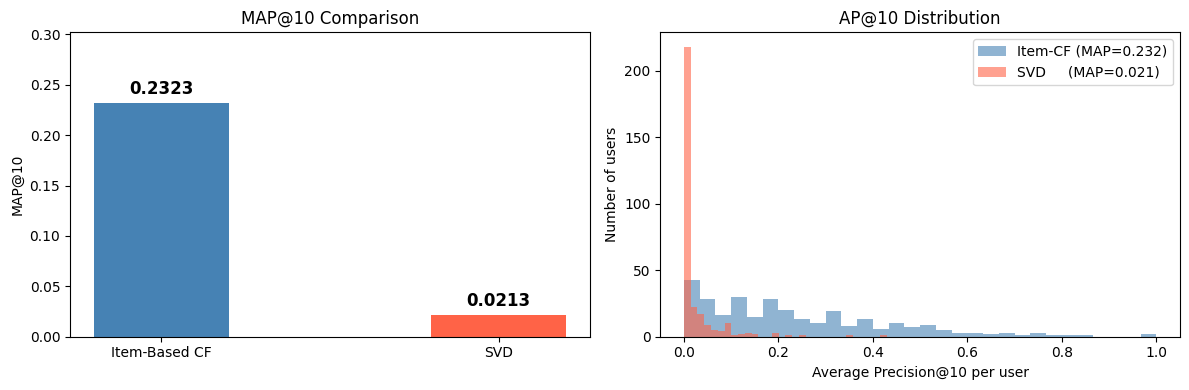

In [12]:
import matplotlib.pyplot as plt

print("=" * 35)
print(f"  Item-CF  MAP@{K} : {map_cf:.4f}")
print(f"  SVD      MAP@{K} : {map_svd:.4f}")
print("=" * 35)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
model_names = ["Item-Based CF", "SVD"]
scores = [map_cf, map_svd]
colors = ["steelblue", "tomato"]
bars = axes[0].bar(model_names, scores, color=colors, width=0.4)
for bar, s in zip(bars, scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{s:.4f}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )
axes[0].set_ylim(0, max(scores) * 1.3)
axes[0].set_ylabel(f"MAP@{K}")
axes[0].set_title(f"MAP@{K} Comparison")

# AP distribution
axes[1].hist(ap_scores_cf,  bins=30, alpha=0.6, label=f"Item-CF (MAP={map_cf:.3f})",  color="steelblue")
axes[1].hist(ap_scores_svd, bins=30, alpha=0.6, label=f"SVD     (MAP={map_svd:.3f})", color="tomato")
axes[1].set_xlabel(f"Average Precision@{K} per user")
axes[1].set_ylabel("Number of users")
axes[1].set_title("AP@10 Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9. RMSE Evaluation

Calculate Root Mean Squared Error (RMSE) for both models on the test set to evaluate prediction accuracy.

In [13]:
from sklearn.metrics import mean_squared_error

# Function to predict rating for Item-CF
def predict_rating_item_cf(user_id, movie_id, n_neighbors=40):
    """Predict rating using Item-Based CF"""
    if user_id not in user_movie_train.index:
        return 3.0  # default
    
    watched = user_movie_train.loc[user_id].dropna()
    if len(watched) == 0:
        return 3.0  # default
    
    score = 0.0
    total_sim = 0.0
    
    for watched_movie, rating in watched.items():
        if watched_movie not in similarity_df.columns or movie_id not in similarity_df.columns:
            continue
        sim = similarity_df.loc[movie_id, watched_movie]
        score += sim * rating
        total_sim += abs(sim)
    
    if total_sim == 0:
        return 3.0
    return score / total_sim

# Collect test predictions for Item-CF
test_users_cf = test_df["user_id"].unique()
y_true_cf = []
y_pred_cf = []

for _, row in test_df.iterrows():
    user_id = row["user_id"]
    movie_id = row["movie_id"]
    actual_rating = row["rating"]
    pred_rating = predict_rating_item_cf(user_id, movie_id)
    
    y_true_cf.append(actual_rating)
    y_pred_cf.append(pred_rating)

# Calculate RMSE for Item-CF
rmse_cf = np.sqrt(mean_squared_error(y_true_cf, y_pred_cf))
print(f"Item-CF RMSE: {rmse_cf:.4f}")

# Collect test predictions for SVD
y_true_svd = []
y_pred_svd = []

for _, row in test_df.iterrows():
    user_id = row["user_id"]
    movie_id = row["movie_id"]
    actual_rating = row["rating"]
    pred_rating = svd_model.predict(user_id, movie_id).est
    
    y_true_svd.append(actual_rating)
    y_pred_svd.append(pred_rating)

# Calculate RMSE for SVD
rmse_svd = np.sqrt(mean_squared_error(y_true_svd, y_pred_svd))
print(f"SVD RMSE:      {rmse_svd:.4f}")


Item-CF RMSE: 0.9596
SVD RMSE:      0.8475



COMPREHENSIVE MODEL COMPARISON

Ranking Quality (MAP@10):
  Item-CF  MAP@10 : 0.2323
  SVD      MAP@10 : 0.0213
  Winner   : Item-CF (+0.2111)

Prediction Accuracy (RMSE):
  Item-CF RMSE: 0.9596
  SVD     RMSE: 0.8475
  Winner  : SVD (0.1121 better)


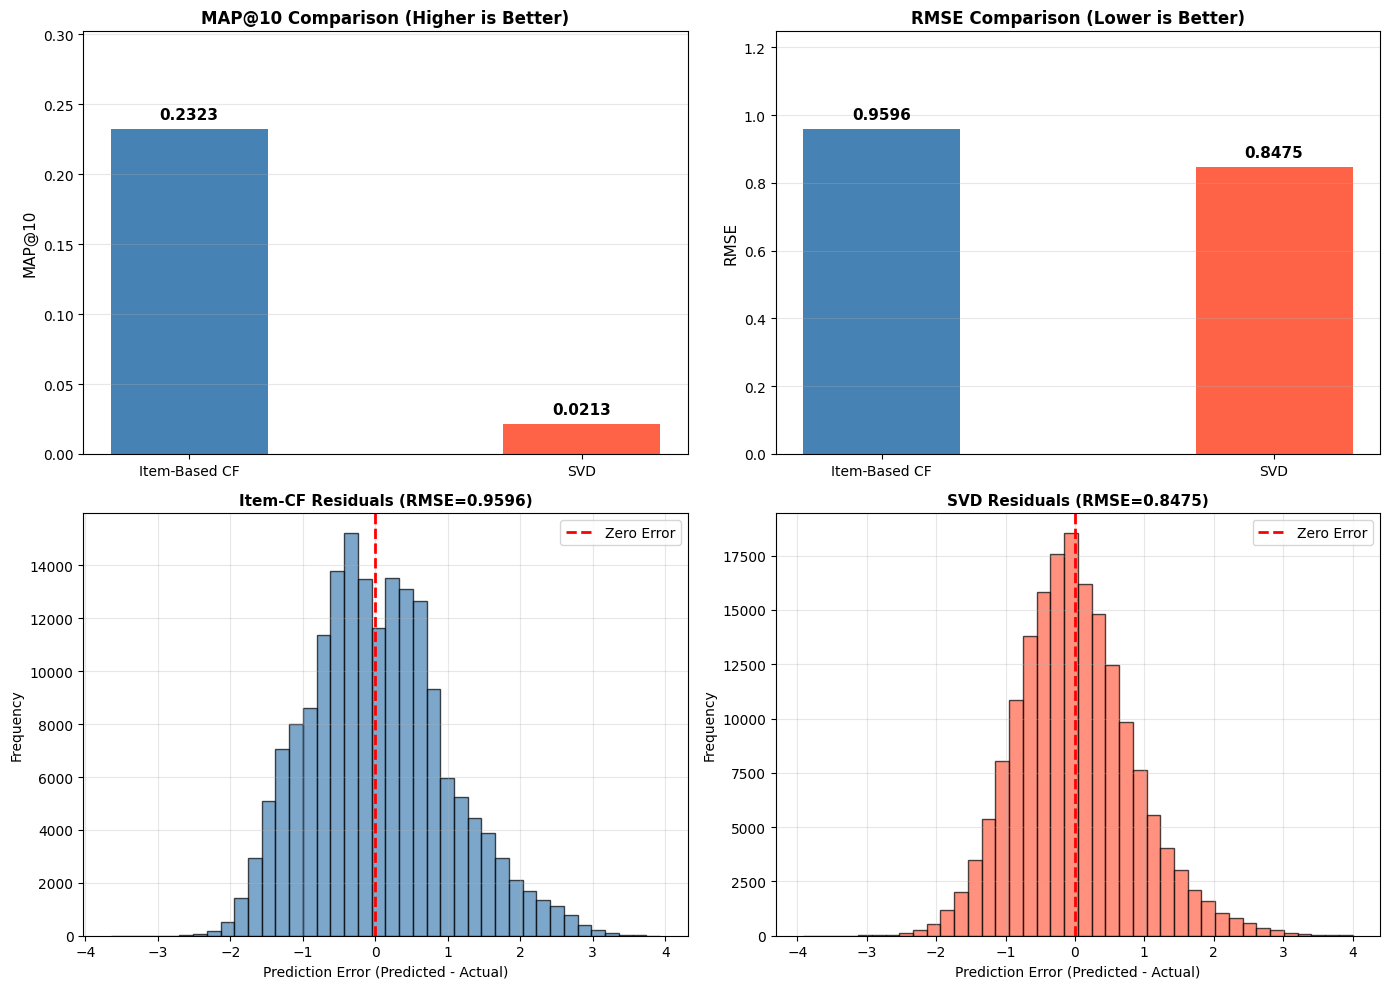

In [14]:
# Summary comparison: MAP vs RMSE
print("\n" + "=" * 50)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 50)
print(f"\nRanking Quality (MAP@{K}):")
print(f"  Item-CF  MAP@{K} : {map_cf:.4f}")
print(f"  SVD      MAP@{K} : {map_svd:.4f}")
print(f"  Winner   : {'Item-CF' if map_cf > map_svd else 'SVD'} (+{abs(map_cf - map_svd):.4f})")

print(f"\nPrediction Accuracy (RMSE):")
print(f"  Item-CF RMSE: {rmse_cf:.4f}")
print(f"  SVD     RMSE: {rmse_svd:.4f}")
print(f"  Winner  : {'Item-CF' if rmse_cf < rmse_svd else 'SVD'} ({abs(rmse_cf - rmse_svd):.4f} better)")
print("=" * 50)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAP Comparison
model_names = ["Item-Based CF", "SVD"]
map_scores = [map_cf, map_svd]
colors_map = ["steelblue", "tomato"]
bars1 = axes[0, 0].bar(model_names, map_scores, color=colors_map, width=0.4)
for bar, s in zip(bars1, map_scores):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{s:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0, 0].set_ylim(0, max(map_scores) * 1.3)
axes[0, 0].set_ylabel(f"MAP@{K}", fontsize=11)
axes[0, 0].set_title(f"MAP@{K} Comparison (Higher is Better)", fontsize=12, fontweight="bold")
axes[0, 0].grid(axis="y", alpha=0.3)

# Plot 2: RMSE Comparison
rmse_scores = [rmse_cf, rmse_svd]
colors_rmse = ["steelblue", "tomato"]
bars2 = axes[0, 1].bar(model_names, rmse_scores, color=colors_rmse, width=0.4)
for bar, s in zip(bars2, rmse_scores):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"{s:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0, 1].set_ylim(0, max(rmse_scores) * 1.3)
axes[0, 1].set_ylabel("RMSE", fontsize=11)
axes[0, 1].set_title("RMSE Comparison (Lower is Better)", fontsize=12, fontweight="bold")
axes[0, 1].grid(axis="y", alpha=0.3)

# Plot 3: Residuals for Item-CF
residuals_cf = np.array(y_pred_cf) - np.array(y_true_cf)
axes[1, 0].hist(residuals_cf, bins=40, color="steelblue", alpha=0.7, edgecolor="black")
axes[1, 0].axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")
axes[1, 0].set_xlabel("Prediction Error (Predicted - Actual)", fontsize=10)
axes[1, 0].set_ylabel("Frequency", fontsize=10)
axes[1, 0].set_title(f"Item-CF Residuals (RMSE={rmse_cf:.4f})", fontsize=11, fontweight="bold")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Residuals for SVD
residuals_svd = np.array(y_pred_svd) - np.array(y_true_svd)
axes[1, 1].hist(residuals_svd, bins=40, color="tomato", alpha=0.7, edgecolor="black")
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")
axes[1, 1].set_xlabel("Prediction Error (Predicted - Actual)", fontsize=10)
axes[1, 1].set_ylabel("Frequency", fontsize=10)
axes[1, 1].set_title(f"SVD Residuals (RMSE={rmse_svd:.4f})", fontsize=11, fontweight="bold")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
